In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import xesmf as xe                     # package for regridding 
#import cartopy.crs as ccrs              # for the regridding test(now only to understand how it works later maybe more - probably I can do a lot with this package

#import gravity toolkit 
import gravity_toolkit as gravtk

#from scipy import signal              #not sure if I need those
#import importlib

import Kyrafunctions as ky

import sys
sys.path.append('../code')


import SeaLevelContrib as slc


In [2]:
data_path = '../data/GravIs/'
output_path = '../outputs/Antarcticatest'

<xarray.Dataset> Size: 22MB
Dimensions:   (time: 240, y: 97, x: 117)
Coordinates:
  * x         (x) float64 936B -2.9e+06 -2.85e+06 -2.8e+06 ... 2.85e+06 2.9e+06
  * y         (y) float64 776B -2.4e+06 -2.35e+06 -2.3e+06 ... 2.35e+06 2.4e+06
  * time      (time) datetime64[ns] 2kB 2002-04-18 ... 2024-12-16T12:00:00
Data variables:
    time_dec  (time) float64 2kB ...
    lon       (y, x) float64 91kB ...
    lat       (y, x) float64 91kB ...
    dm        (time, y, x) float64 22MB ...
    area      (y, x) float64 91kB ...
    crs       |S1 1B ...
Attributes: (12/16)
    title:                Gridded AIS Mass Changes
    institution:          TU Dresden, Chair of Geodetic Earth System Research
    authors:              Andreas Groh, Martin Horwath, Thorben Döhne
    project:              GravIS GRACE/GRACE-FO Level-3 Products
    source:               Monthly COST-G RL01 GRACE/GRACE-FO Level-2B product...
    summary:              GRACE/GRACE-FO derived time series of gridded Antar...
    ...                   ...
    product_version:      0003
    doi:                  10.5880/COST-G.GRAVIS_01_L3_ICE
    netCDF_version:       netCDF-4_classic
    conventions:          CF-1.6
    date_created:         2025-04-07
    contact:              thorben.doehne@tu-dresden.de

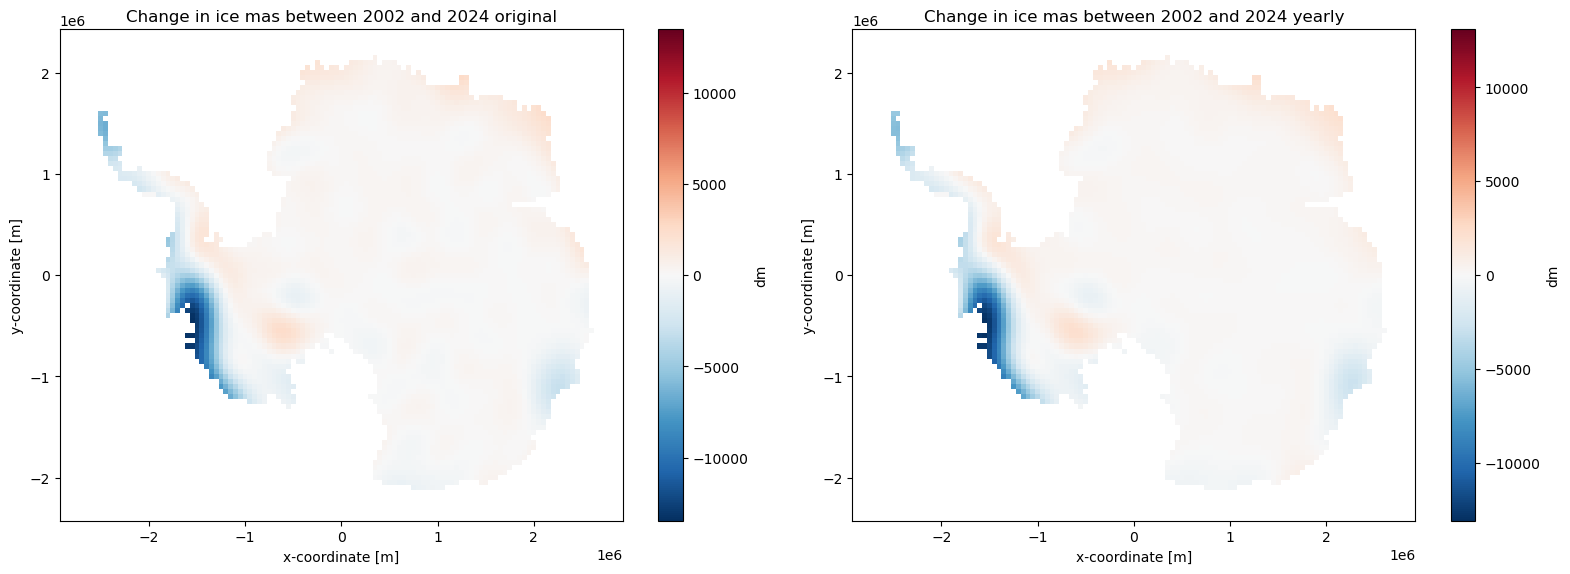

max_y
2204.1654761904756
max_orig
2557.3999999999996
Number of non-NaNs in dm_y: 112516


<xarray.Dataset> Size: 2MB
Dimensions:   (y: 97, x: 117, time: 23)
Coordinates:
  * x         (x) float64 936B -2.9e+06 -2.85e+06 -2.8e+06 ... 2.85e+06 2.9e+06
  * y         (y) float64 776B -2.4e+06 -2.35e+06 -2.3e+06 ... 2.35e+06 2.4e+06
  * time      (time) datetime64[ns] 184B 2002-12-31 2003-12-31 ... 2024-12-31
Data variables:
    lon       (y, x) float64 91kB ...
    lat       (y, x) float64 91kB ...
    area      (y, x) float64 91kB ...
    crs       |S1 1B ...
    dm        (time, y, x) float64 2MB nan nan nan nan nan ... nan nan nan nan
    time_dec  (time) int64 184B 2002 2003 2004 2005 2006 ... 2021 2022 2023 2024
Attributes: (12/16)
    title:                Gridded AIS Mass Changes
    institution:          TU Dresden, Chair of Geodetic Earth System Research
    authors:              Andreas Groh, Martin Horwath, Thorben Döhne
    project:              GravIS GRACE/GRACE-FO Level-3 Products
    source:               Monthly COST-G RL01 GRACE/GRACE-FO Level-2B product...
    summary:              GRACE/GRACE-FO derived time series of gridded Antar...
    ...                   ...
    product_version:      0003
    doi:                  10.5880/COST-G.GRAVIS_01_L3_ICE
    netCDF_version:       netCDF-4_classic
    conventions:          CF-1.6
    date_created:         2025-04-07
    contact:              thorben.doehne@tu-dresden.de

['2002-04-18T00:00:00.000000000' '2002-05-10T00:00:00.000000000'
 '2002-08-16T12:00:00.000000000' '2002-09-16T00:00:00.000000000'
 '2002-10-16T12:00:00.000000000' '2002-11-16T00:00:00.000000000'
 '2002-12-16T12:00:00.000000000' '2003-01-16T12:00:00.000000000'
 '2003-02-15T00:00:00.000000000' '2003-03-16T12:00:00.000000000'
 '2003-04-16T00:00:00.000000000' '2003-05-11T12:00:00.000000000'
 '2003-07-16T12:00:00.000000000' '2003-08-16T12:00:00.000000000'
 '2003-09-16T00:00:00.000000000' '2003-10-16T12:00:00.000000000'
 '2003-11-16T00:00:00.000000000' '2003-12-16T12:00:00.000000000'
 '2004-01-07T12:00:00.000000000' '2004-02-17T00:00:00.000000000'
 '2004-03-16T12:00:00.000000000' '2004-04-16T00:00:00.000000000'
 '2004-05-16T12:00:00.000000000' '2004-06-16T00:00:00.000000000'
 '2004-07-16T12:00:00.000000000' '2004-08-16T12:00:00.000000000'
 '2004-09-16T00:00:00.000000000' '2004-10-16T12:00:00.000000000'
 '2004-11-16T00:00:00.000000000' '2004-12-16T12:00:00.000000000'
 '2005-01-16T12:00:00.000

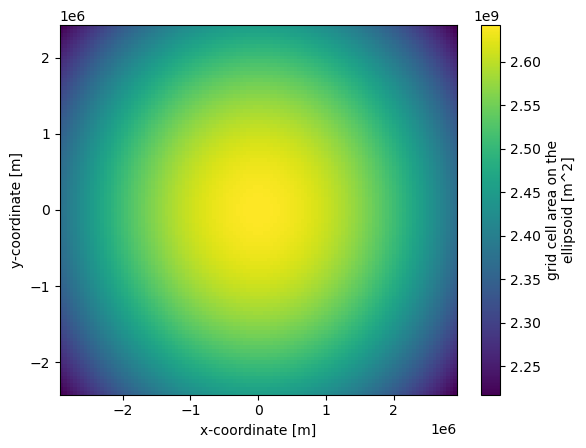

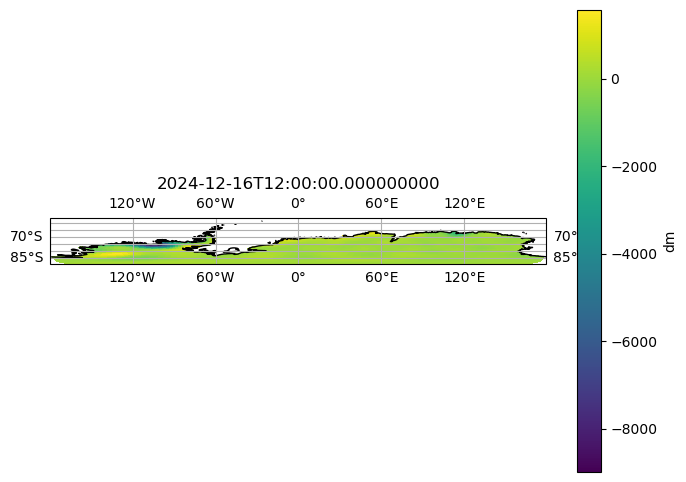

In [3]:
#Open the COST-G and GFZ dataset to compare 
ant = xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_AIS_GRID_TUD_0003.nc")
ant2 = xr.open_dataset(data_path + "GRAVIS-3_GFZOP_0600_AIS_GRID_TUD_0004.nc")

gre = xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_GIS_GRID_TUD_0003.nc")

#print(ant)
#dm = ant['dm']

display(ant)

# Drop dm, time_dec, and the old time coordinate: this is everything that dempends on time
ant_y = ant.drop_vars(['dm', 'time_dec', 'time'], errors='ignore')
gre_y = gre.drop_vars(['dm', 'time_dec', 'time'], errors='ignore')

# Resample dm to yearly
dm_y = ant['dm'].resample(time='1Y').mean(keep_attrs=True)
dm_y_g = gre['dm'].resample(time='1Y').mean(keep_attrs=True)
#dm_y = ant['dm'].groupby('time.year').mean()
#dm_y = ant['dm'].resample(time='A-JUN').mean(keep_attrs=True)

# Ensure correct order
dm_y = dm_y.transpose('time', 'y', 'x')
dm_y_g = dm_y_g.transpose('time', 'y', 'x')

# Assign dm back
ant_y = ant_y.assign({'dm': dm_y})
gre_y = gre_y.assign({'dm': dm_y_g})


# Assign the time coordinate from dm_y (now no conflicts)
ant_y = ant_y.assign_coords(time=dm_y['time'])
gre_y = gre_y.assign_coords(time=dm_y_g['time'])

# Compute decimal year as a NumPy array
time_dec = ant_y["time"].dt.year 
time_dec_g = gre_y["time"].dt.year 


# Add it as a new variable (not just a coordinate)
ant_y["time_dec"] = ("time", time_dec.data)
gre_y["time_dec"] = ("time", time_dec_g.data)

# Add metadata (optional but good practice)
ant_y["time_dec"].attrs = {
    "long_name": "Decimal year",
    "units": "year"
}

gre_y["time_dec"].attrs = {
    "long_name": "Decimal year",
    "units": "year"
}

# plot the two difference figures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

(ant['dm'].isel(time=-1)-ant['dm'].isel(time=0)).plot(ax=ax1, cmap='RdBu_r')
ax1.set_title('Change in ice mas between 2002 and 2024 original')

(ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)).plot(ax=ax2, cmap='RdBu_r')
ax2.set_title('Change in ice mas between 2002 and 2024 yearly')
plt.tight_layout()
plt.show()
max_y = (ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)).max()
print('max_y')
print(max_y.values)
max_orig = (ant['dm'].isel(time=-1) - ant['dm'].isel(time=0)).max()
print('max_orig')
print(max_orig.values)


# Check number of non-NaNs
print("Number of non-NaNs in dm_y:", dm_y.count().values)
      
display(ant_y)
print(ant['time'].values)
#print(ant_y['time_dec'].values)

ant['area'].plot()

##################################################################################################

import cartopy.crs as ccrs

# Select one timestep to plot (e.g., last one)
dm_plot = ant['dm'].isel(time=-1)

# Get lon and lat arrays
lon = ant['lon']
lat = ant['lat']

# Create figure
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and gridlines
ax.coastlines()
ax.gridlines(draw_labels=True)

# Plot using pcolormesh
mesh = ax.pcolormesh(lon, lat, dm_plot, transform=ccrs.PlateCarree())
plt.colorbar(mesh, ax=ax, label="dm")

plt.title(str(ant['time'].isel(time=-1).values))
plt.show()




In [4]:
print('hoi') 

hoi


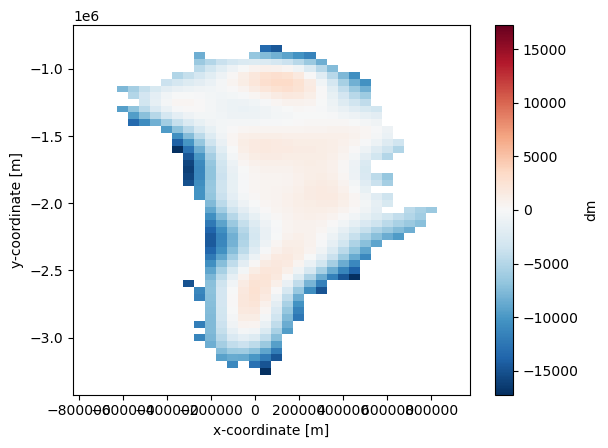

In [5]:

(gre['dm'].isel(time=-1)-gre['dm'].isel(time=0)).plot(cmap='RdBu_r')
plt.show()

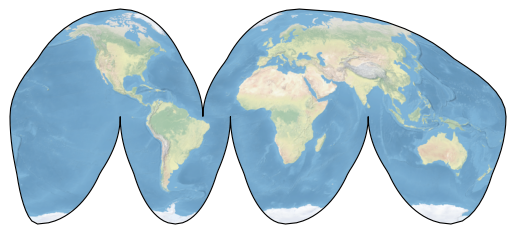

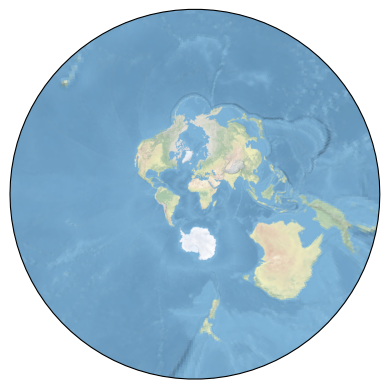

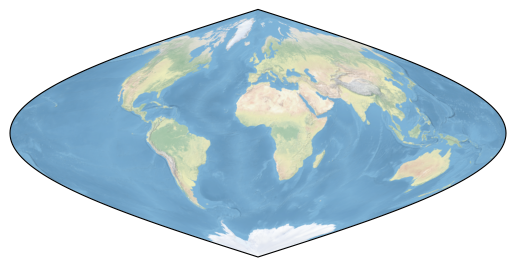

In [6]:
ax = plt.axes(projection=ccrs.InterruptedGoodeHomolosine(central_longitude=0, globe=None))
ax.stock_img()
plt.show()


ax = plt.axes(projection=ccrs.Stereographic())
ax.stock_img()
plt.show()


ax = plt.axes(projection=ccrs.Sinusoidal())
ax.stock_img()
plt.show()

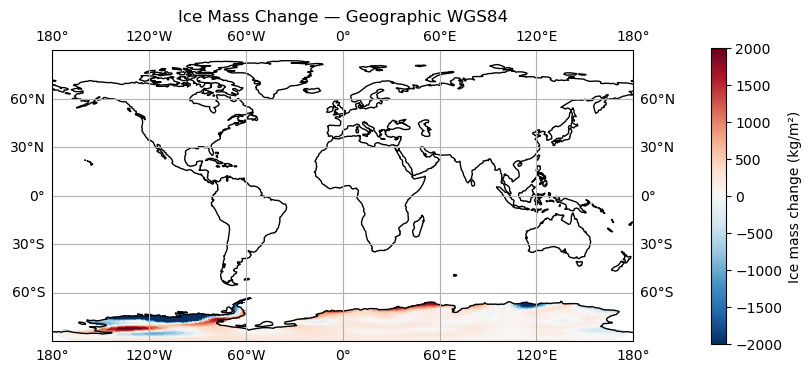

In [7]:
import cartopy.crs as ccrs

# Define geographic WGS84 axes (lon/lat)
geo_crs = ccrs.PlateCarree()  # Correct capitalization
#geo_crs = ccrs.AlbersEqualArea(central_longitude=0.0, central_latitude=0.0, false_easting=0.0, false_northing=0.0, standard_parallels=(20.0, 50.0), globe=None)

# Create figure and axis
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=geo_crs)

# Add coastlines and gridlines
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)

# Set extent over Antarctica
ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())

# Plot your data
mesh = ax.pcolormesh(
    ant_y['lon'], ant_y['lat'], (ant_y['dm'].isel(time=-1)-ant_y['dm'].isel(time=0)),
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-2000, vmax=2000
)

# Colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.64, aspect=20, pad=0.1)
cbar.set_label('Ice mass change (kg/m²)')

plt.title("Ice Mass Change — Geographic WGS84")
plt.show()


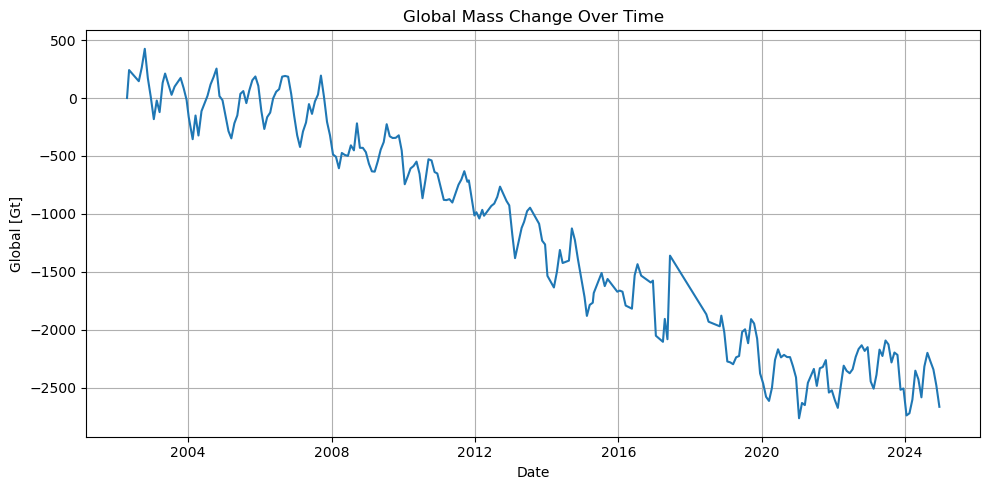

          0          1         2        3        4        5        6   \
0  2002.2932   783.5572 -185.5918  21.7319 -92.8456 -18.4564 -81.2985   
1  2002.3534  1024.7474 -143.0508  13.9175 -61.2555 -13.2401 -70.6948   
2  2002.6233   928.5683 -150.1679  30.4260 -84.9035 -19.0654 -45.7729   
3  2002.7068  1045.5888 -170.5825  35.6658 -74.4790 -21.7441 -32.0139   
4  2002.7904  1208.1679 -153.6786  36.2826 -40.3099 -10.9531 -46.8552   

        7        8         9   ...      43      44      45      46      47  \
0 -63.9005 -97.4660 -116.6008  ...  6.3730  4.5306  4.2031  5.4707  8.9105   
1 -53.3779 -91.2150 -107.0281  ...  6.3562  4.5186  4.1920  5.4562  8.8869   
2 -45.5895 -87.8541 -121.8660  ...  5.1408  3.6547  3.3905  4.4130  7.1877   
3 -53.1359 -88.1752 -119.4560  ...  6.4417  4.5795  4.2484  5.5297  9.0065   
4 -37.6079 -98.1817  -87.3465  ...  4.7231  3.3577  3.1149  4.0544  6.6036   

       48       49       50      51       52  
0  9.5865  10.6224  10.5266  8.2482  10.2016 

In [8]:
# yearly data from website

#gravis_data = pd.read_csv(data_path + 'AIS_COSTG_0100_0003.csv', usecols=['time [yyyy-mm-dd]', 'global [Gt]'])
gravis_data = pd.read_csv(data_path + 'AIS_COSTG_0100_0003.csv')
gravis_data_gre = pd.read_csv(data_path + 'GIS_COSTG_0100_0003.csv')
#print(gravis_data)

# Convert the time column to datetime
gravis_data['time [yyyy-mm-dd]'] = pd.to_datetime(gravis_data['time [yyyy-mm-dd]'])
Gravistest = gravis_data['global [Gt]'] - gravis_data['global [Gt]'][0]

gravis_data_gre['time [yyyy-mm-dd]'] = pd.to_datetime(gravis_data_gre['time [yyyy-mm-dd]'])
Gravistest_gre = gravis_data_gre['global [Gt]'] - gravis_data_gre['global [Gt]'][0]

#print(Gravistest)

plt.figure(figsize=(10, 5))
plt.plot(gravis_data['time [yyyy-mm-dd]'], Gravistest)
plt.title('Global Mass Change Over Time')
plt.xlabel('Date')
plt.ylabel('Global [Gt]')
plt.grid(True)
plt.tight_layout()
plt.show()

#display(gravis_data) 

import pandas as pd

# Read the ASC file
df = pd.read_csv(data_path + "GRAVIS-3_COSTG_0100_AIS_BAVE_AWI_0003.asc", 
                 comment="#",  # Ignore lines starting with #
                 delim_whitespace=True,  # Space-delimited
                 header=None)  # No column names in the file

# Show first rows
print(df.head())


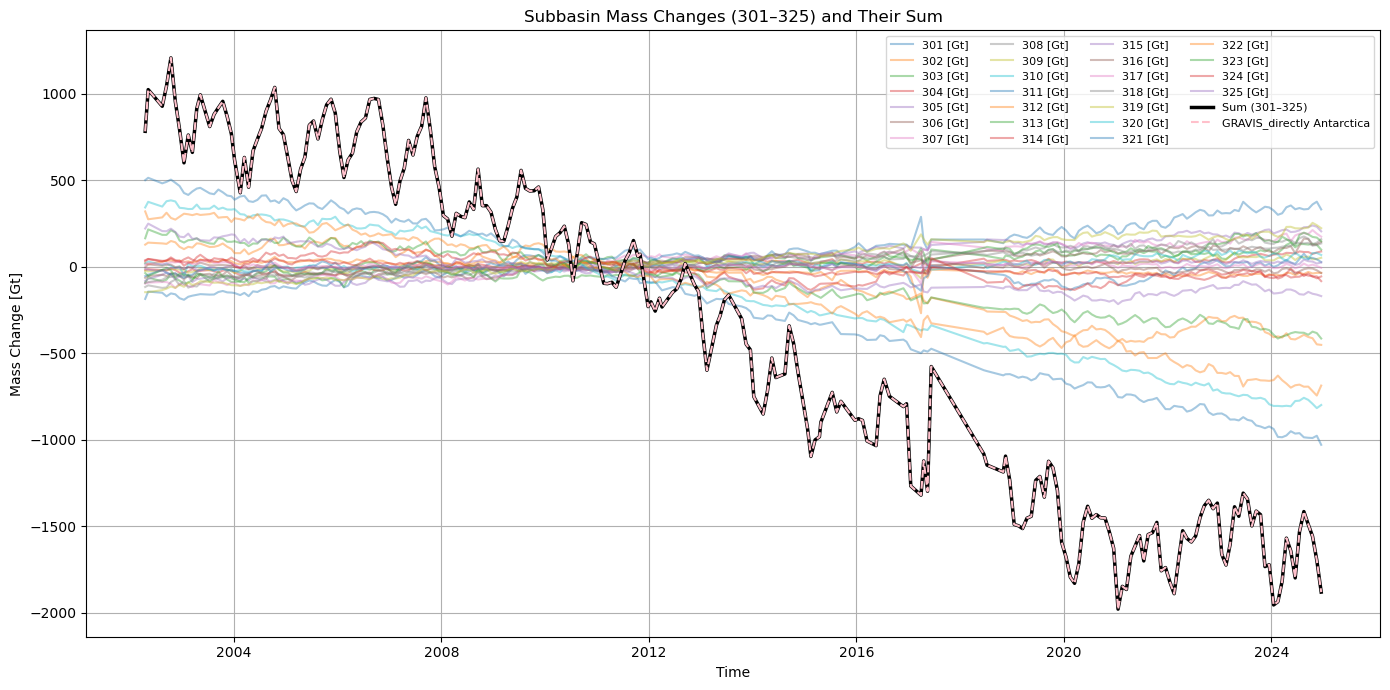

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

'''
# Select only basin columns (exclude uncertainties and previously created sum columns)
basin_cols = [
    col for col in gravis_data.columns
    if any(f"{i} [Gt]" in col for i in range(301, 326))
    and not col.startswith("uncertainty_")
    and not col.startswith("sum_")
]

# Sort correctly by basin number
basin_cols = sorted(basin_cols, key=lambda x: int(x.split()[0]))
'''

# --- Select only the basin columns between 301 and 325 ---
basin_cols = [f"{i} [Gt]" for i in range(301, 326) if f"{i} [Gt]" in gravis_data.columns]

# Compute total sum across selected basins
gravis_data["sum_301_325 [Gt]"] = gravis_data[basin_cols].sum(axis=1)

# Plot
plt.figure(figsize=(14, 7))

for col in basin_cols:
    plt.plot(gravis_data["time [yyyy-mm-dd]"], gravis_data[col], alpha=0.4, label=col)

plt.plot(
    gravis_data["time [yyyy-mm-dd]"],
    gravis_data["sum_301_325 [Gt]"],
    color='black', linewidth=2.5, label='Sum (301–325)'
)

plt.plot(gravis_data['time [yyyy-mm-dd]'], gravis_data['global [Gt]'], label='GRAVIS_directly Antarctica', color='pink', linestyle='--', marker='')

plt.title("Subbasin Mass Changes (301–325) and Their Sum")
plt.xlabel("Time")
plt.ylabel("Mass Change [Gt]")
plt.legend(ncol=4, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
antsumyear = (ant_y['dm']*ant['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12) 

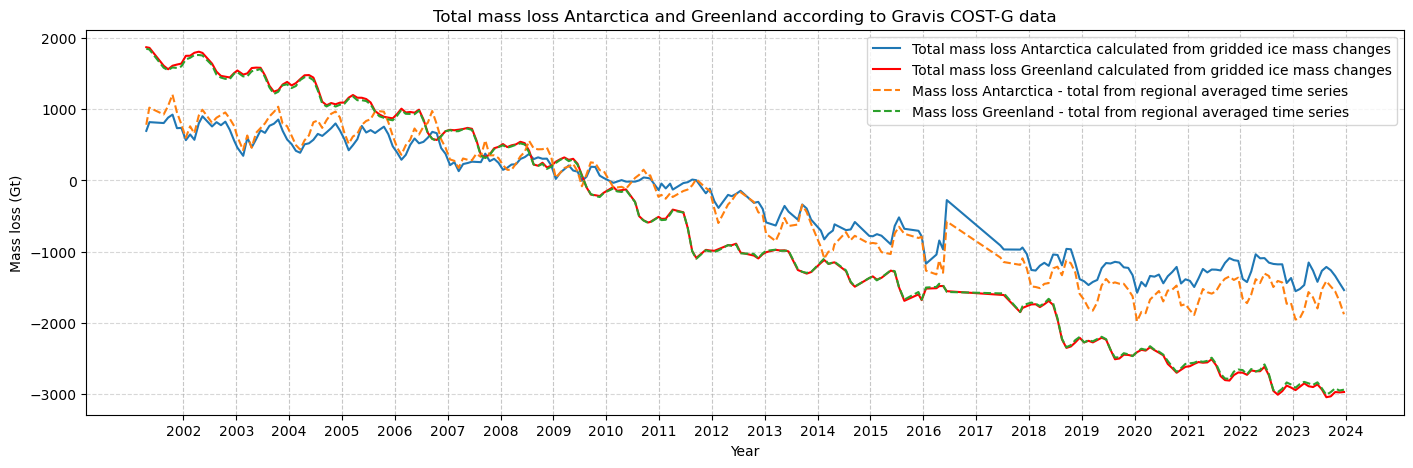

In [17]:

# Create dataset with total mass loss over Antarctica for the 2 datasets. 

antsum = (ant['dm']*ant['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12)  # Multiply the dm (kg per square meter ice losOk s) with the area to ge total ice loss, then sum over all cells to get total mass loss and translate to Gt
antsum2 = (ant2['dm']*ant2['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12)

antsum_twee = (ant['dm']*50000**2).sum(dim=['x', 'y'], skipna=True)*10**(-12)
Greensum = (gre['dm']*gre['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12)



#double defined now:
antsumyear = (ant_y['dm']*ant['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12) 
greensumyear = (gre_y['dm']*gre['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12) 



plt.figure(figsize=(17,5)) 
antsum.plot(label='Total mass loss Antarctica calculated from gridded ice mass changes', linestyle='-')
#(antsum*1.2).plot(label='Total mass loss Antarctica calculated from gridded ice mass changes multiplied by factor 1.2', linestyle='-')
Greensum.plot(label='Total mass loss Greenland calculated from gridded ice mass changes', linestyle='-', color = 'red' )
plt.plot(gravis_data['time [yyyy-mm-dd]'], gravis_data['global [Gt]'], label='Mass loss Antarctica - total from regional averaged time series', linestyle='--', marker='')
plt.plot(gravis_data_gre['time [yyyy-mm-dd]'], gravis_data_gre['global [Gt]'], label='Mass loss Greenland - total from regional averaged time series', linestyle='--', marker='')

#antsumyear.plot(label  = 'antsumyear')
#greensumyear.plot(label = 'greensumyear')


plt.legend()
plt.xlabel('Year')
plt.ylabel('Mass loss (Gt)')
plt.title("Total mass loss Antarctica and Greenland according to Gravis COST-G data")

# ✅ Use time coordinate for x-ticks (one per year)
plt.xticks(antsumyear["time"].values)

# ✅ Vertical gridlines for each year
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# ✅ Add horizontal gridlines too
plt.grid(True, axis='y', linestyle='--', alpha=0.5)


plt.show()
#antsum = (ant_dm*ant['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12)  # plot the yearly data
#antsum2 = (ant2['dm']*ant2['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12)





Skipping field extent: unsupported OGR type: 3


<class 'dict'>
dict_keys(['type', 'features'])
   set  calc  display name       changed  \
0  GIS  True     True  301  1.747299e+09   
1  GIS  True     True  302  1.747299e+09   
2  GIS  True     True  303  1.747299e+09   
3  GIS  True     True  304  1.747299e+09   
4  GIS  True     True  305  1.747299e+09   

                                                hash  \
0  sha256:e1cfe5764c9ac1900a82fe1f9a4ccd025b5a585...   
1  sha256:798880f2932a62a4e166ff21f1895a2de662cc0...   
2  sha256:b4e696d38041e9d09530df0279916376eec6bb4...   
3  sha256:4b5a8d517eefcd4e61551825ca852a625d861e6...   
4  sha256:98ba0884ecff433c97bab3171a8ac41684f23a2...   

                                            geometry  
0  MULTIPOLYGON (((-45.34019 76.72251, -45.34019 ...  
1  MULTIPOLYGON (((-20.35821 81.95072, -20.35821 ...  
2  MULTIPOLYGON (((-34.82043 66.33534, -35.03969 ...  
3  MULTIPOLYGON (((-42.37747 62.40456, -42.37747 ...  
4  MULTIPOLYGON (((-43.96234 59.83276, -43.96234 ...  
EPSG:4326


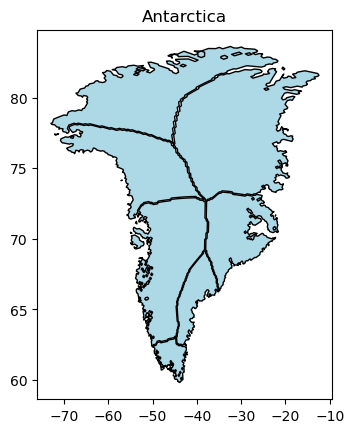

Total area of Antarctica: 1.266e+16 m²


In [12]:
import json

# Open the GeoJSON file

with open(data_path + "greenland.geojson") as f:
    data = json.load(f)

# Check the type of data
print(type(data))  # usually dict
print(data.keys())  # usually ['type', 'features']

import geopandas as gpd

gdf = gpd.read_file(data_path+ 'greenland.geojson')

# Inspect the data
print(gdf.head())
print(gdf.crs)  # check the coordinate reference system

# Simple plot
gdf.plot(edgecolor='black', facecolor='lightblue')
plt.title("Antarctica")
plt.show()


# Project to a CRS with meters
gdf_m = gdf.to_crs(epsg=3031)

# Calculate area in square kilometers
gdf_m["area_km2"] = gdf_m.geometry.area  # m^2 → km^2

# Total area of Antarctica
total_area = gdf_m["area_km2"].sum()
print(f"Total area of Antarctica: {total_area:.3e} m²")



Original CRS: EPSG:4326
Number of polygons: 7
Total area of Antarctica: 12661883145.21 km²


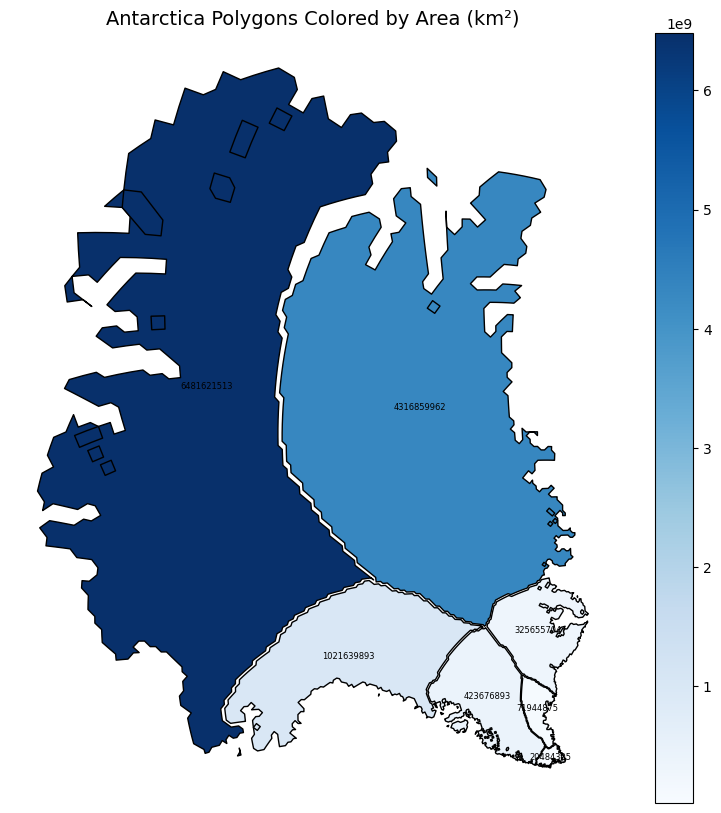

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt


print("Original CRS:", gdf.crs)
print("Number of polygons:", len(gdf))

# --- 2️⃣ Reproject to Antarctic Polar Stereographic (EPSG:3031) ---
gdf_m = gdf.to_crs(epsg=3031)

# --- 3️⃣ Calculate area in km² ---
gdf_m["area_km2"] = gdf_m.geometry.area / 1e6  # m² -> km²
total_area = gdf_m["area_km2"].sum()
print(f"Total area of Antarctica: {total_area:.2f} km²")

# --- 4️⃣ Plot polygons colored by area ---
fig, ax = plt.subplots(figsize=(10, 10))
gdf_m.plot(column="area_km2", cmap="Blues", legend=True, edgecolor='black', ax=ax)
ax.set_title("Antarctica Polygons Colored by Area (km²)", fontsize=14)

# --- 5️⃣ Optional: label each polygon with its area ---
for idx, row in gdf_m.iterrows():
    # use centroid for label
    if row["geometry"].geom_type == 'Polygon' or row["geometry"].geom_type == 'MultiPolygon':
        centroid = row["geometry"].centroid
        ax.text(centroid.x, centroid.y, f"{row['area_km2']:.0f}", fontsize=6, ha='center', va='center')

plt.axis('off')
plt.show()


2002-04-18 00:00:00 2024-12-16 00:00:00
2002-04-18T00:00:00.000000000 2024-12-16T12:00:00.000000000
Average mass loss rate (COST-G): -112.83 Gt/yr
Average mass loss rate (GFZ):    -107.43 Gt/yr
TOTAL MASS LOSS BETWEEN 2002 AND 2024:-2174420518290746.75 kg


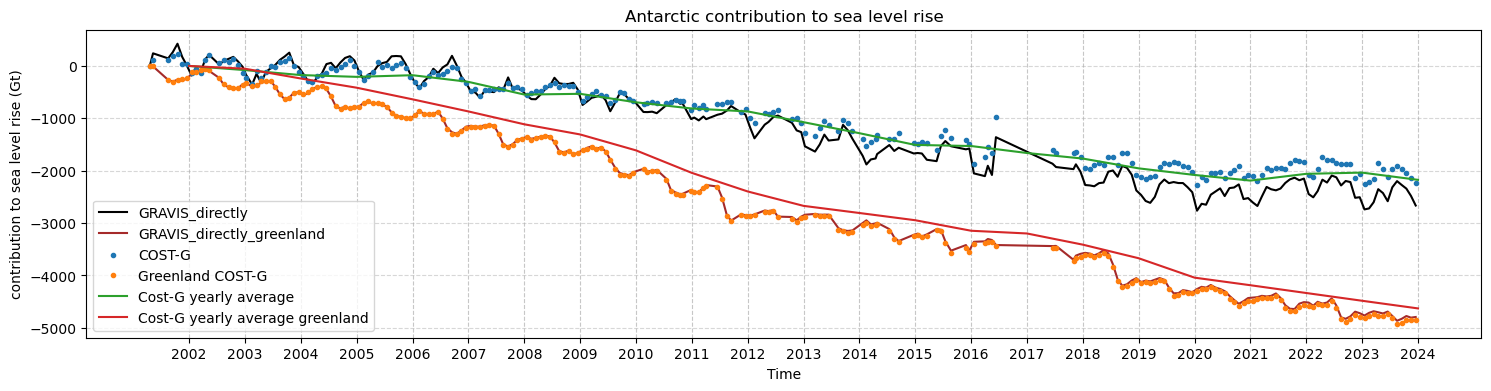

In [14]:



# Represent values relative to the value at t=0
antsum_rel = antsum - antsum.isel(time=0)
antsum2_rel = antsum2 - antsum2.isel(time=0)
antsum_twee_rel = antsum_twee - antsum_twee.isel(time=0)

greensum_rel = Greensum - Greensum.isel(time=0)

print(gravis_data['time [yyyy-mm-dd]'].min(), gravis_data['time [yyyy-mm-dd]'].max())
print(antsum_rel['time'].min().values, antsum_rel['time'].max().values)


#Determine the trend - CHECK THIS CODE
# Make numeric array of years plus fractin of the days. 
time_years = antsum['time'].dt.year + antsum['time'].dt.dayofyear / 365.25
time_years2 = antsum2['time'].dt.year + antsum2['time'].dt.dayofyear / 365.25
# Linear trend (slope = Gt/yr)
slope1, intercept1 = np.polyfit(time_years, antsum_rel, 1)
slope2, intercept2 = np.polyfit(time_years2, antsum2_rel, 1)
print(f"Average mass loss rate (COST-G): {slope1:.2f} Gt/yr")
print(f"Average mass loss rate (GFZ):    {slope2:.2f} Gt/yr")


# Check total mass loss between 2002 and now based on ant_y

antsumyear = (ant_y['dm']*ant['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12) 
greensumyear = (gre_y['dm']*gre['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12) 


totalmassant = (antsumyear.isel(time=-1)-antsumyear.isel(time=0))*1e12 #from gt back to kg
print(f"TOTAL MASS LOSS BETWEEN 2002 AND 2024:{totalmassant:.2f} kg")




#Make a figure 
plt.figure(figsize=(18,4)) 


plt.plot(gravis_data['time [yyyy-mm-dd]'], Gravistest, label='GRAVIS_directly', color='black', linestyle='-', marker='')
plt.plot(gravis_data_gre['time [yyyy-mm-dd]'], Gravistest_gre, label='GRAVIS_directly_greenland', color='brown', linestyle='-', marker='')
#antsum_rel
#antsum_twee_rel.plot(marker='.', linestyle='-', label='COST-G test')
antsum_rel.plot(marker='.', linestyle='', label='COST-G') #multiply antsum by 1.2 to line up with the black line.. .that is weird 
greensum_rel.plot(marker='.', linestyle='', label='Greenland COST-G') #multiply antsum by 1.2 to line up with the black line.. .that is weird 

#antsum2_rel.plot(marker='.', linestyle='', label='GFZ')
((antsumyear-antsumyear.isel(time=0))).plot(label='Cost-G yearly average') #scaled by factor 1.2')
((greensumyear-greensumyear.isel(time=0))).plot(label='Cost-G yearly average greenland')  #scaled by factor 1.2')

# ✅ Use time coordinate for x-ticks (one per year)
plt.xticks(antsumyear["time"].values)

# ✅ Vertical gridlines for each year
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# ✅ Add horizontal gridlines too
plt.grid(True, axis='y', linestyle='--', alpha=0.5)


plt.xlabel("Time")
plt.ylabel("contribution to sea level rise (Gt)")
plt.title("Antarctic contribution to sea level rise")
plt.legend()
plt.show()



In [15]:
print(ant['area'].mean().values)
print(ant['area'].min().values)
print(ant['area'].max().values)
print(50000**2)


mask = ant['dm'].isel(time=0).notnull()
valid_fraction = mask.sum() / (mask.sizes['x'] * mask.sizes['y'])
print("valid fraction:", float(valid_fraction))


# assume `basin_ts` is the GravIS basin total in Gt for the same times
ratio = gravis_data['global [Gt]'].mean() / ((ant['dm']*ant['area']).sum(dim=['x', 'y'], skipna=True)*10**(-12)).mean()
print("median ratio:", float(ratio.median()))

2487936012.8838987
2217500966.692505
2641925415.71875
2500000000
valid fraction: 0.4310511939377919
median ratio: 1.2390935979393967


## Try to calculate the total mass loss Antarctica

In [16]:
#check times
#time_list = antsum["time"].dt.strftime("%Y-%m-%d").values
#print(time_list)
#print(antsum['dm'].values)
# antsum is your 1D DataArray: sum over all coordinates per timestep
#antsum_interp = antsum.interpolate_na(dim="time", method="linear")
#antsum_interp.plot(marker='.', linestyle='', figsize=(12,4))



## Regridding to use GRD in the proper grid (lon, lat grid) 

In [ ]:
# Define the reference mask: 

path_masks = '/Users/kyrab/Github/SLBudget/data/Masks/'
masks_ds = xr.open_dataset(f'{path_masks}reference_masks.nc')

landsea = xr.where(masks_ds.mask==1, 0, 1)
landsea.plot()
print(masks_ds['lat'].values)

landsea


In [ ]:
# Regridding 

#define resolution reference grid (needs to have the same dimensions as the mask
#lon_res = 1
#lat_res = 1

#lon_target = np.arange(0, 360 , lon_res)
#lat_target = np.arange(-90, 90 , lat_res)  # (this should be until 90+lat_res otherwise you miss one pole??


# Or use the lon and lat values from the mask directly: Here, points are defined between 2 degrees. It contains for lat all values 89.5 - N*1 with N in N
lon_target = masks_ds['lon'].values
lat_target = masks_ds['lat'].values 


lon2d, lat2d = np.meshgrid(lon_target, lat_target)   #creats lon lat pairs


# CHECK WHY THIS IS EXactly 
ds_out = xr.Dataset(
    {
        "lat": (["lat", "lon"], lat2d),
        "lon": (["lat", "lon"], lon2d)
    }
)


# Create the regridder. Array dataset containin lat lon values. 
regridder1 = xe.Regridder(ant, ds_out, "bilinear", periodic=True, reuse_weights=False, unmapped_to_nan=True)
regridder = xe.Regridder(ant_y, ds_out, "bilinear", periodic=True, reuse_weights=False, unmapped_to_nan=True)  # periodic should be true


# Regrid dm to lon-lat grid
dm_lonlat1 = regridder1(ant["dm"], keep_attrs=True)
dm_lonlat = regridder(ant_y["dm"], keep_attrs=True)
# Optional: Regrid area too if you need to recompute total mass
#area_lonlat = regridder(ant_y["area"], keep_attrs=True)


# Replace NANs with zeros: then there will be no mass change at areas that are not defined in the ant map
dm_lonlat_zero1 = dm_lonlat1.fillna(0)
dm_lonlat_zero = dm_lonlat.fillna(0) 

#area_lonlat_zero = area_lonlat.fillna(0)


# Compute total mass per time step in Gt ---
# 1 Gt = 1e12 kg
#total_mass_gt = (dm_lonlat_zero * area_lonlat_zero).sum(dim=("lat", "lon")) * 1e-12
#print(total_mass_gt)


'''
# --- Step 5: Store in xarray dataset for saving / plotting ---
ds_mass = xr.Dataset(
    {
        "dm_lonlat": dm_lonlat,
        "area_lonlat": area_lonlat,
        "total_mass_gt": total_mass_gt
    },
    coords={
        "time": ant_y["time"],
        "lat": (["lat", "lon"], lat2d),
        "lon": (["lat", "lon"], lon2d)
    }
)

# --- save to netcdf??
#ds_mass.to_netcdf("dm_lonlat_mass.nc")

'''

#plot 1
totalant1 = dm_lonlat_zero1.isel(time=-1) - dm_lonlat_zero1.isel(time=0)
totalant = dm_lonlat_zero.isel(time=-1) - dm_lonlat_zero.isel(time=0)
#totalant = dm_lonlat.isel(time=-1) - dm_lonlat.isel(time=0)
totalant_withnan = dm_lonlat.isel(time=-1) - dm_lonlat.isel(time=0)

#Make a figure: 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

totalant1.plot(ax=ax1, cmap="RdBu_r", vmin=-2000, vmax=2000,
        cbar_kwargs={
        'label': 'Ice mass change (kg/m²)',
        'shrink':1,                # Scale colorbar size
        'aspect':20   # in this case it is 20 times longer than it is wide            
    }
)
ax1.set_title('Change in ice mas between 2002 and 2024 original data')
#min and max values for plot 1
min_val1 = totalant1.min().values
max_val1 = totalant1.max().values
ax1.text(0.02, 0.98, f'Min: {min_val1:.1f} kg/m²\nMax: {max_val1:.1f} kg/m²',
         transform=ax1.transAxes, 
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         fontsize=10)


totalant.plot(ax=ax2, cmap="RdBu_r", vmin=-2000, vmax=2000,
        cbar_kwargs={
        'label': 'Ice mass change (kg/m²)',
        'shrink':1,                # Scale colorbar size
        'aspect':20   # in this case it is 20 times longer than it is wide            
    }
)
ax2.set_title('Change in ice mas between 2002 and 2024 yearly data')
# Add min/max text to plot 2
min_val2 = totalant.min().values
max_val2 = totalant.max().values
ax2.text(0.02, 0.98, f'Min: {min_val2:.1f} kg/m²\nMax: {max_val2:.1f} kg/m²',
         transform=ax2.transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         fontsize=10)
plt.tight_layout()
plt.show()

#totalant



# Save as NetCDF file
#totalant.to_netcdf(output_path + 'totalant_mass_change.nc')

# Later, reopen it:
#totalant_loaded = xr.open_dataarray(output_path + 'totalant_mass_change.nc')
#totalant_loaded.plot()
#totalant_loaded.close()


In [ ]:
print('Doe het even')

In [ ]:

import cartopy.crs as ccrs

# Define the Antarctic Polar Stereographic projection (EPSG:3031)
antarctic_crs = ccrs.SouthPolarStereo()

# Create a single plot (not a subplot grid)
plt.figure(figsize=(8, 8))
#ax = plt.axes(projection=antarctic_crs)
ax = plt.axes(projection=antarctic_crs)

# Add context layers
ax.coastlines()#resolution='110m', color='black', linewidth=0.8)
#ax.gridlines(draw_labels=False, color='gray', linestyle='--', linewidth=0.5)
#ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())  # view over Antarctica
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())  # view over Antarctica

# Plot the data
mesh = ax.pcolormesh(
    totalant['lon'], totalant['lat'], totalant,
    #landsea['lon'], landsea['lat'], landsea,
    transform=ccrs.PlateCarree(),  # because lon/lat are in degrees (WGS84)
    cmap="RdBu_r",
    vmin=-2000, vmax=2000
)

# Add colorbar
cbar = plt.colorbar(
    mesh, ax=ax, orientation='vertical',
    shrink=0.8, aspect=20, pad=0.05,
    label='Ice mass change (kg/m²)'
)

plt.title("Ice Mass Change — Antarctic Polar Stereographic", fontsize=12)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

antarctic_crs = ccrs.SouthPolarStereo()

plt.figure(figsize=(8, 8))
ax = plt.axes(projection=antarctic_crs)

ax.coastlines()
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

# Plot ice mass change
mesh = ax.pcolormesh(
    landsea['lon'], landsea['lat'], landsea,
    transform=ccrs.PlateCarree(),
    cmap='Greys_r',    # white=land, black=sea
    alpha=0.4
)
# Overlay the land-sea mask
ax.pcolormesh(
    landsea['lon'], landsea['lat'], landsea,
    transform=ccrs.PlateCarree(),
    cmap='Greys_r',
    alpha=0.3
)

# Colorbar
cbar = plt.colorbar(
    mesh, ax=ax, orientation='vertical',
    shrink=0.8, aspect=20, pad=0.05,
    label='Ice mass change (kg/m²)'
)

plt.title("Ice Mass Change — Antarctic Polar Stereographic", fontsize=12)
plt.show()


In [ ]:
# Calculate the colatitude in radians: 

th = (90 - lat_target)*np.pi/180.0
LMAX = 360
LOVE = gravtk.load_love_numbers(LMAX)
PLM, dPLM = gravtk.plm_holmes(LMAX, np.cos(th))
LOVE0 = (LOVE[0]-LOVE[0], LOVE[1]-LOVE[1], LOVE[2]-LOVE[2])


In [ ]:
# Method 2 from notebook ComputeGRD
#tptalant=dm_diff
#It uses a dinsity of 1 standard but that is not realistic I think??? SOLVE THIS!!
Ylms = gravtk.gen_stokes(totalant.data.T, lon_target, lat_target, UNITS=3, LMIN=0, LMAX=LMAX, LOVE=LOVE, PLM=PLM)
Ylms_L0 = gravtk.gen_stokes(totalant.data.T, lon_target, lat_target, UNITS=3, LMIN=0, LMAX=LMAX, LOVE=LOVE0, PLM=PLM)
#Ylms = gravtk.gen_stokes(dm_diff.data.T, lon_target, lat_target, UNITS=3, LMIN=0, LMAX=LMAX, LOVE=LOVE, PLM=PLM)
#Ylms_L0 = gravtk.gen_stokes(dm_diff.data.T, lon_target, lat_target, UNITS=3, LMIN=0, LMAX=LMAX, LOVE=LOVE0, PLM=PLM)



Ylms

print("Ylms.clm shape:", Ylms.clm.shape)
print("lon_target:", len(lon_target))
print("lat_target:", len(lat_target))
print("landsea shape:", landsea.shape)
print('lalal')

In [ ]:
rsl = gravtk.sea_level_equation(Ylms.clm, Ylms.slm, lon_target, lat_target, landsea.data.T,
    LMAX=LMAX, PLM=PLM, LOVE=LOVE, ITERATIONS=6, POLAR=True)

rsl_da = xr.DataArray(
    data=rsl.T,              # transpose if needed
    dims=["lat", "lon"],     # match array shape
    coords={"lat": lat_target, "lon": lon_target}
)

#rsl_da.plot(robust=True, cmap="RdBu_r")

#rsl_da = xr.DataArray(data=rsl, 
#                       dims=['lon', 'lat'],
#                      coords=['lon': lon_target, 'lat': lat_target])

#rsl_da.T.plot(robust=True)


# Convert longitudes from 0–360 to -180–180
#rsl_da = rsl_da.assign_coords(lon=(((rsl_da.lon + 180) % 360) - 180))

# Sort by longitude so that it plots correctly
#rsl_da = rsl_da.sortby('lon')



# Now plot again
(rsl_da/22).plot(robust=True, cmap="RdBu_r")
plt.title('Sea level rise due to Antarctic melt 2002-2024')

rsl_da

In [ ]:
# Check if the total addeed mass is equal to the total mass loss of antarctica


# First, compute the area of each cell

# Get the average radius of the eath [cm] using LMAX (same method as in GRD patterns) 
factors = gravtk.units(lmax=LMAX)
rad_e = factors.rad_e/10**5 # Convert to km
rad_e_m = rad_e*1000 #convert to meters

area_da = landsea.copy()

deg2rad = np.pi/180
area_d1 = rad_e_m**2*np.cos(area_da.lat*deg2rad)*deg2rad**2   #calculate for every lat and lon combination the area. actually it depends only on latitude 

area_da.data = area_d1.data[:,np.newaxis]*np.ones(len(area_da.lon))

area_da.name = 'cell area [m**2]'
#area_da.plot()

# Check the computation of the area is done in compute grd patterns and there it is shown it is similar
#earth_surf_area = 4*np.pi*rad_e**2
#print('Analytical computation')
#print(earth_surf_area)
#print('Sum of grid')
#print(area_da.sum().data)

oc_vol_change = area_da*rsl_da/100 #assuming rsl is given in cm
tot_vol_change = oc_vol_change.sum()

rho = 1000 #kg/m3
total_kig_added = tot_vol_change*rho  #assuming for now 1000 kg/m3, the same as used in the GRD patterns now

#print('kg added')
#print(total_kig_added.data)
print(f"🌊 Total added water mass to the ocean:                          {total_kig_added.data:,.15e} kg")


# Check total mass loss between 2002 and now based on ant_y

antsumyear = (ant['dm']*ant_y['area']).sum(dim=['x', 'y'], skipna=True)    # ant/y in kg/m^2 per year and area in m2.. 


totalmassant = (antsumyear.isel(time=-1) - antsumyear.isel(time=0))         #from gt back to kg
#print(f"TOTAL MASS LOSS BETWEEN 2002 AND 2024:{totalmassant1:.3e} kg")

print(f"🧊 Total mass loss Antarctica between 2002 and 2024:            {totalmassant:.15e} kg")

#now calculate the total removed mass according to the regridded map: 
regriddedchange = area_da * totalant 
regriddedchange_tot = regriddedchange.sum()
print(f"🏔  Total mass decrease Antarctica calculated after regridding:  {regriddedchange_tot:.15e} kg")



maskje1=xr.where(np.isnan((ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0))), 0, 1)
areabeforeregridding = (ant_y['area']*maskje1).sum(dim=['x', 'y'], skipna=True)
#areabeforeregridding = ant_y['area'].sum(dim=['x', 'y'], skipna=True)
print('Total area before regridding')
print(f"{areabeforeregridding.values:.3e}")


#create a mask array which is 1 for all totalant_withnan values with valid data
maskje = xr.where(np.isnan(totalant_withnan), 0, 1)

areaafterregridding = area_da*maskje
totalareaafter = areaafterregridding.sum()
print('Total area after regridding')
print(f"{totalareaafter.values:.3e}")

areadif = areabeforeregridding - totalareaafter
print('Difference in area in m2')
print(f"{areadif.values:.3e}")



# assume a mass loss of 10000 kg/m2 on average for missing areas
print('missing mass losss in Gt')
print((areadif*10000*10**(-12)).values)


differenceloss = totalmassant - regriddedchange_tot
print('Difference in mass loss in gt')
print(differenceloss.values*10**(-12))


In [ ]:
import cartopy.crs as ccrs
import numpy as np
import matplotlib.pyplot as plt

antarctic_crs = ccrs.SouthPolarStereo()

diff = ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)

# Automatically get min and max of data
#vmin = np.nanmin(diff)
#vmax = np.nanmax(diff)

# Create both subplots with the same projection
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 8),
    subplot_kw={'projection': antarctic_crs}
)

# --- Left subplot: Antarctic map ---
ax1.coastlines()
ax1.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())

mesh1 = ax1.pcolormesh(
    totalant_withnan['lon'], totalant_withnan['lat'], totalant_withnan, #areaafterregridding,#totalant_withnan,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    vmin=-2000, vmax=2000
)
ax1.set_title(f"Ice mass change after regridding (2002–2024), total area: {totalareaafter:.3e} m²")

# --- Right subplot: Antarctic map ---
diff = ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)

mesh2 = ax2.pcolormesh(
    ant_y['lon'], ant_y['lat'], diff, # (ant_y['area']*maskje1), # diff,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    vmin=-2000, vmax=2000
)
ax2.coastlines()
ax2.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
ax2.set_title(f"Change in Ice Mass before regridding, total area: {areabeforeregridding:.3e} m²")

# --- Shared colorbar ---
cbar = fig.colorbar(mesh2, ax=[ax1, ax2], orientation='horizontal', fraction=0.05, pad=0.07)
cbar.set_label('Ice mass change (kg/m²)')

plt.show()


print('minimum before regridding')
print(diff.min().values)
print('miniumum after regridding')
print(totalant.min().values)

In [ ]:
import cartopy.crs as ccrs
import numpy as np
from matplotlib.colors import TwoSlopeNorm

antarctic_crs = ccrs.SouthPolarStereo()


diff = ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)

# Automatically get min and max of data
vmin = np.nanmin(diff)
vmax = np.nanmax(diff)

# Set midpoint at 0
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)



# Create both subplots with the same projection
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 8),
    subplot_kw={'projection': antarctic_crs}#,
   # constrained_layout=True  # keeps equal scaling
)

# --- Left subplot: Antarctic map ---
ax1.coastlines()#resolution='110m', color='black', linewidth=0.8)
ax1.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())

mesh1 = ax1.pcolormesh(
    totalant_withnan['lon'], totalant_withnan['lat'], totalant_withnan,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r'#, vmin=-2000, vmax=2000
    , norm=norm  #only test this
)
ax1.set_title(f"Ice mass change after regridding (2002-2024), total area: {totalareaafter:.3e} m2")


# --- Right subplot: Antarctic map (same projection!) ---
diff = ant_y['dm'].isel(time=-1) - ant_y['dm'].isel(time=0)
mesh2 = ax2.pcolormesh(
    ant_y['lon'], ant_y['lat'], diff,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r'#, vmin=-2000, vmax=2000
    , norm=norm
)
ax2.coastlines()
ax2.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
ax2.set_title(f"Change in Ice Mass before regridding, total area: {areabeforeregridding:.3e} m2")

# --- Shared colorbar ---
cbar = fig.colorbar(mesh2, ax=[ax1, ax2], orientation='horizontal', fraction=0.05, pad=0.07)
cbar.set_label('Ice mass change (kg/m²)')

plt.show()


In [ ]:
#test with function:



function_rsl = ky.sealevelfunctions(totalant, lon_target, lat_target, landsea)

(function_rsl/22).plot(robust=True, cmap="RdBu_r")



In [ ]:
totalant2 = dm_lonlat_zero.isel(time=-7) - dm_lonlat_zero.isel(time=0) #this is how totalant is calculated for the last year
antreference = dm_lonlat_zero - dm_lonlat_zero.isel(time=0)


results = []
step=2001
for t in antreference.time:
    step=step+1
    print('Jaar')
    print(step) 
    totalant_t = antreference.sel(time=t)
    hoi_t = ky.sealevelfunctions(totalant_t, lon_target, lat_target, landsea)
    results.append(hoi_t)

# Combine all time slices into a single xarray DataArray
hoi_all = xr.concat(results, dim=antreference.time)
hoi_all["time"] = antreference.time



# Plot an example year
hoi_all.isel(time=-1).plot(robust=True, cmap="RdBu_r")

hoi=ky.sealevelfunctions(totalant2, lon_target, lat_target, landsea)

#hoi.plot(robust=True, cmap="RdBu_r")



In [ ]:
#display(hoi_all)
# Plot an example year
hoi_all.isel(time=1).plot(robust=True, cmap="RdBu_r")

hoi=ky.sealevelfunctions(totalant2, lon_target, lat_target, landsea)

#hoi.plot(robust=True, cmap="RdBu_r")


# Pick 9 time indices spanning from 0 to 22 (inclusive)
time_indices = np.linspace(1, 22, 9, dtype=int)

print(time_indices)

# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, ax in enumerate(axes):
    print(i)
    t = time_indices[i]
    time = 2002 + time_indices[i]
    hoi_all.isel(time=t).plot(ax=ax, cmap="RdBu_r", vmin=-0.9, vmax=0.9)
    ax.set_title(f"{time} relative to 2002")

plt.tight_layout()


plt.savefig("C:/Users/kyrab/OneDrive/Afbeeldingen/sealevelrisyears", dpi=300, bbox_inches="tight")

plt.show()


## Create an nc file with yearly increase data

# Compare with frederikse


In [ ]:
fred_dir = '../data/Frederikse2020/'

ant_ds = xr.open_dataset(f'{fred_dir}AIS.nc')

((ant_ds['AIS_rsl_mean'].isel(time=-1)-ant_ds['AIS_rsl_mean'].isel(time=102))).plot(robust=True, cmap="RdBu_r")


plt.title('2002-2018 frederikse avg per year')
plt.show()

frederikse2018 = ((ant_ds['AIS_rsl_mean'].sel(time=2018)-ant_ds['AIS_rsl_mean'].sel(time=2002)))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

(frederikse2018*0.1).plot(ax=ax1, cmap="RdBu_r", vmin=-2, vmax=2)
ax1.set_title('Frederikse 2018 relative to 2002 in cm')

hoi_all.isel(time=16).plot(ax=ax2, cmap="RdBu_r", vmin=-2, vmax=2) #, vmin=-2000, vmax=2000,
ax2.set_title('Gravis 2018 relative to 2002 in cm')

#ant_ds['AIS_rsl_mean'].isel(time=-1).plot(robust=True, cmap="RdBu_r")
#plt.show()


display(hoi_all)

In [ ]:
#Create same kind of dataset: 

# Other things to try 
Soort of interpolation try but fail

In [ ]:
# Step 1 — Interpolate missing months along the time dimension
dm_interp = ant["dm"].interpolate_na(dim="time", method="linear")

# Step 2 — Group by year and sum (combine all months of each year)
dm_yearly_sum = dm_interp.groupby("time.year").sum(dim="time")

# Step 3 — Convert 'year' to datetime-like coordinate for easy plotting
dm_yearly_sum = dm_yearly_sum.assign_coords(
    time=("year", [np.datetime64(f"{y}-07-01") for y in dm_yearly_sum.year.values])
).swap_dims({"year": "time"}).drop_vars("year")

# Step 4 — (optional) Plot one yearly field, e.g. 2015
dm_yearly_sum.sel(time="2015-07-01").plot(cmap="RdBu_r", robust=True)
plt.title("Annual Sum of Mass Anomaly (COST-G GRAVIS-3, interpolated months)")
plt.show()

# Step 5 — (optional) Area-weighted annual mean time series
dm_annual_mean = (dm_yearly_sum * ant["area"]).sum(dim=("y", "x")) / ant["area"].sum()
plt.figure(figsize=(10,5))
plt.plot(dm_annual_mean["time"], dm_annual_mean, marker="o")
plt.title("Area-weighted Annual Mean (cm w.e.) — COST-G GRAVIS-3")
plt.ylabel("Mass anomaly (cm water equivalent)")
plt.xlabel("Year")
plt.grid(True)
plt.show()